# (22) mnist + conv

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from main.config_defaults import default_configs
from figures.convergence import plot_convergence
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Poisson + MNIST

**Task:** reproduce gold standard

Dataset: ```MNIST```

### Get configs

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|conv')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 2/16 * t_train

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

120000

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  1.3 Mil   |
|     ———     |    ———     |
|    layer    |  1.3 Mil   |
+-------------+------------+

poisson_MNIST_t-16_b-2_k-64_<ngd|conv>
b200-ep400-lr(0.002)_temp(0.05:0.5)_gr(150)_(2025_05_29,08:13)

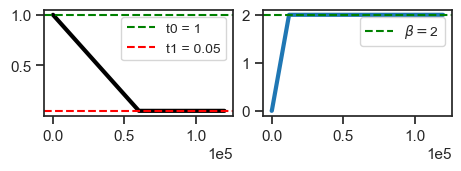

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  1.3 Mil   |
|     ———      |    ———     |
|    fc_dec    |   66.6 K   |
|     dec      |  1.2 Mil   |
|    u_init    |     64     |
+--------------+------------+

In [7]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50],
       device='cuda:1', dtype=torch.int32)

In [8]:
model.cfg.track_stats

True

In [9]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 16, 'kl_beta': 2.0, 'n_latents': 64, 'enc_type': 'ngd',
'dec_type': 'conv', 'recon_mode': 'mse', 'dataset': 'MNIST', 'dataset_name': 'MNIST', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 28, 28), 'shape': (-1, 1, 28, 28), 'init_dist': 'normal', 'init_scale': 0.001, 
'clamp_vals': {'u': (7.0,), 'du': (5.0,), 'dec': 3.45}, 'stochastic': True, 'fit_dec_var': False, 'fit_prior': 
True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST_t-16_b-2_k-64_<ngd|conv>', 
'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_MNIST_t-16_b-2_k-64_<ngd|conv>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.002, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0003, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
150, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_const_portion': 
0.001, 'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 
'temp_stop': 0.05}

In [10]:
print(tr.model.layer.dec)

Sequential(
  (0): UnFlatten()
  (1): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=256, out_features=16, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=16, out_features=256, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (2): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (ops): ModuleList(
      (0): ConvLayer(
        (upsample): Upsample(scale_factor=2.0, mode='nearest')
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=8, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=8, out_features=128, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (3): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=8, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=8, out_features=128, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (4): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (ops): ModuleList(
      (0): ConvLayer(
        (upsample): Upsample(scale_factor=2.0, mode='nearest')
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=64, out_features=4, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=64, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (5): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=64, out_features=4, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=64, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (6): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (ops): ModuleList(
      (0): ConvLayer(
        (upsample): Upsample(scale_factor=2.0, mode='nearest')
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=32, out_features=4, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=32, bias=True)
        (3): Sigmoid()
      )
    )
  )
  (7): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
    (se): SELayer(
      (fc): Sequential(
        (0): Linear(in_features=32, out_features=4, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_f

### Fit model

In [11]:
tr.train()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 400, avg loss: 12.605: 100%|██████| 400/400 [21:37:31<00:00, 194.63s/it]


100%|███████████████████████████████████| 3/3 [00:41<00:00, 13.86s/it]


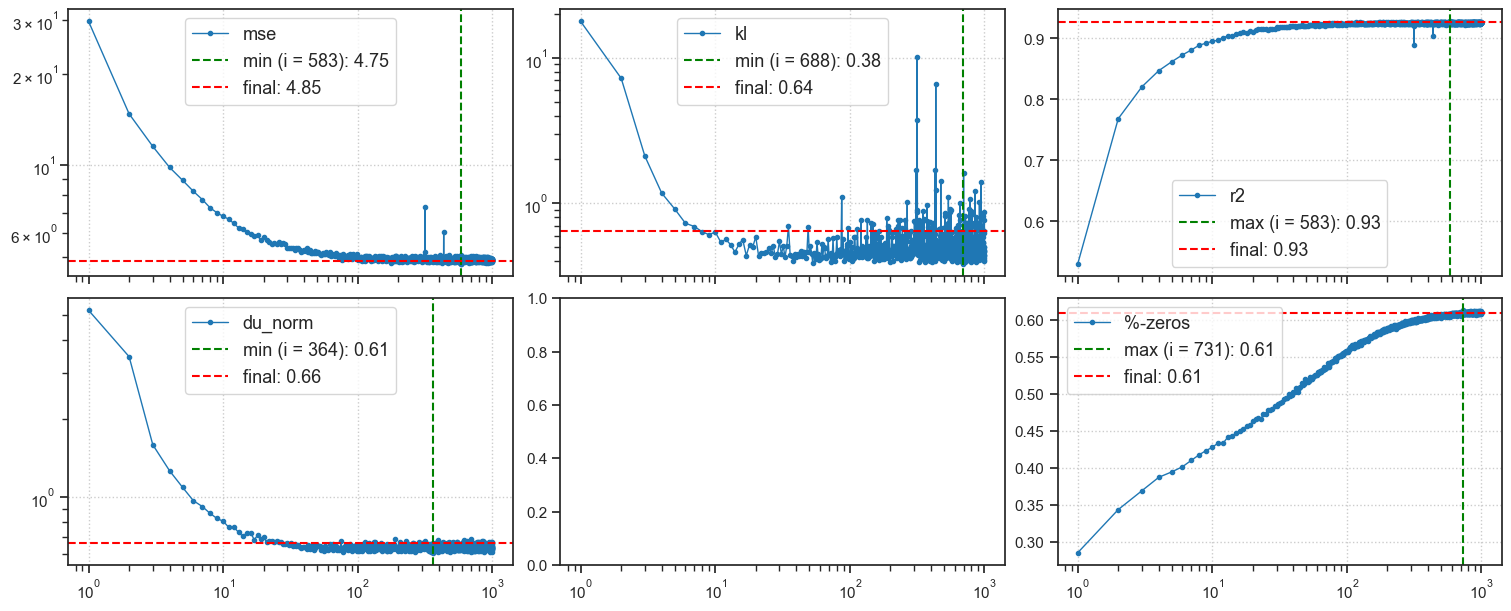

CPU times: user 42.7 s, sys: 101 ms, total: 42.8 s
Wall time: 42.8 s


In [12]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=3,
)
_ = plot_convergence(results, color='C0')

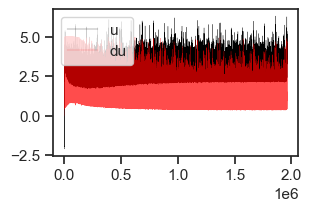

In [13]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

In [14]:
max(tr.model.stats['du_max']), np.quantile(tr.model.stats['du_max'], 0.999)

(5.0, 4.995840074062348)

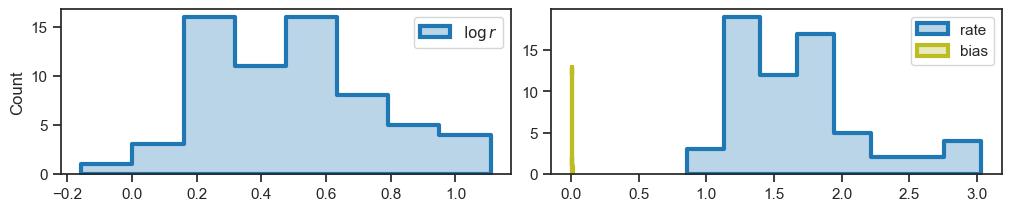

In [15]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [16]:
dead = log_rate < -1
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 64, 0.0)

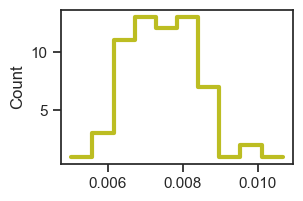

In [17]:
histplot(bias, color='C8', lw=3)
plt.show()

In [18]:
(bias > 0).mean()

1.0

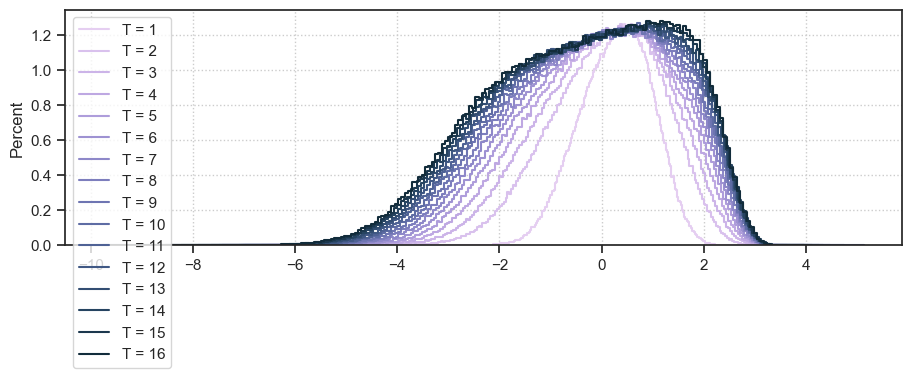

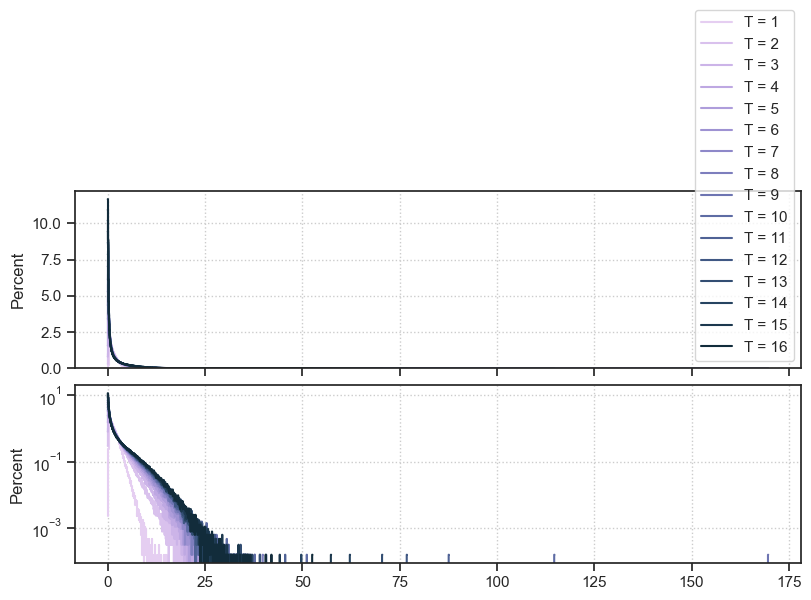

In [19]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [20]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8515783738056356, 0.7564048283277753, 0.9288121656434397],
 [0.8001162997533571, 0.7065759994349422, 0.9086196217899796],
 [0.7439792688412662, 0.6597624126404706, 0.8850042329763351],
 [0.6840855914209351, 0.6156494043651438, 0.8571492616027769],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.5570770035644698, 0.5339111022656235, 0.7863356920291484],
 [0.492099275511766, 0.4953333844045368, 0.7426568873299215],
 [0.4329197631622217, 0.4607041459016169, 0.6976371711644715],
 [0.36977282720352517, 0.4231998490866888, 0.6432078123635816],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.2518347737894646, 0.34677973827838704, 0.5191313564287725],
 [0.1988566031415065, 0.30672139603456333, 0.45066798941042246],
 [0.1509035696744471, 0.2647062105047458, 0.3789955286940389],
 [0.10858527424075325, 0.22023851706947215, 0.30511000295886687],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

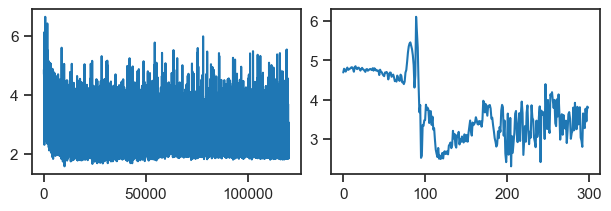

In [24]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [25]:
(grad > 100).sum()

874

100%|█████████████████████████████████| 50/50 [11:32<00:00, 13.85s/it]


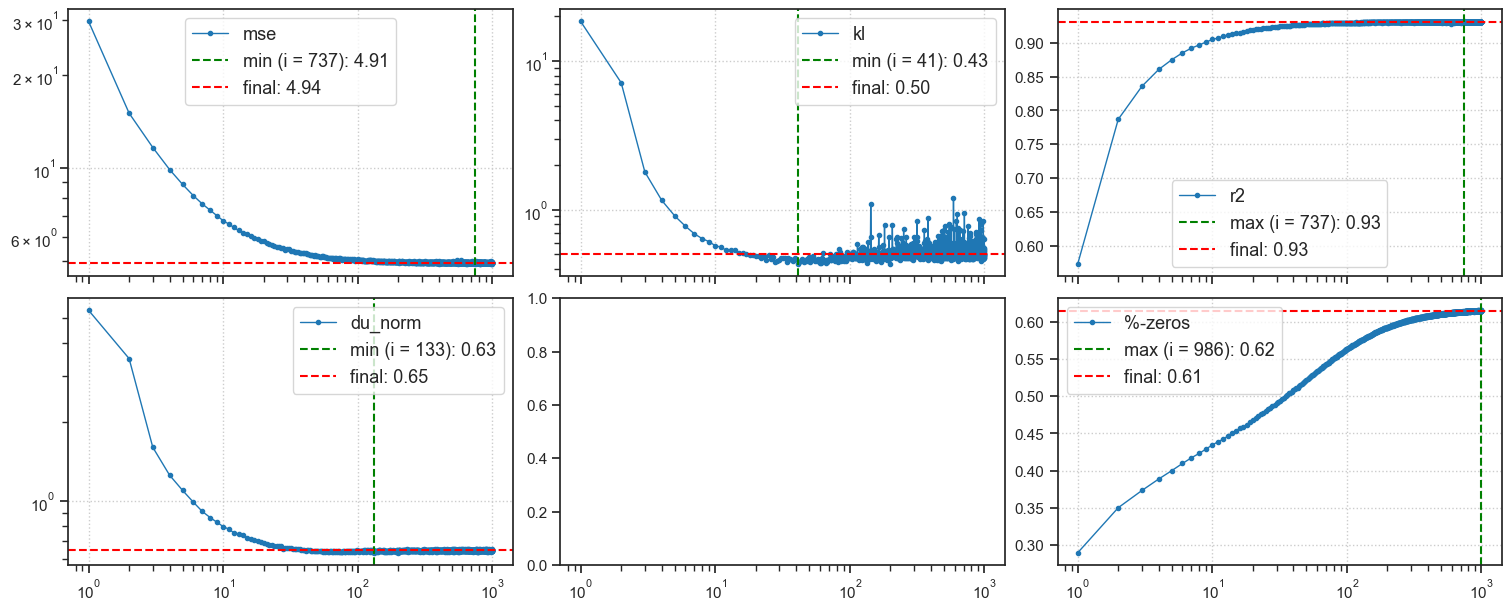

CPU times: user 11min 35s, sys: 1.41 s, total: 11min 37s
Wall time: 11min 36s


In [26]:
%%time

results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=None,
)
_ = plot_convergence(results, color='C0')